In [1]:
import numpy as np
import pandas as pd
import os

# 数据目录
data_dir = "/Users/huangwenqin/Desktop/AIF+CALC+SSF PROJs/CALC_EOCPROJ/python_code/experiment_4/run01"
print(f"数据目录: {data_dir}")

# 角度组：0°~90°
angle_groups = list(range(0, 91))
print(f"角度组: {len(angle_groups)} 个 (0°~90°)")

数据目录: /Users/huangwenqin/Desktop/AIF+CALC+SSF PROJs/CALC_EOCPROJ/python_code/experiment_4/run01
角度组: 91 个 (0°~90°)


In [2]:
# ========== 读取所有 CSV ==========
dfs = {}

for angle in angle_groups:
    base_num = angle_groups.index(angle) * 2 + 1
    micro_num = base_num + 1
    
    base_file = os.path.join(data_dir, f"run_01_angle_{angle:03d}deg_{base_num:03d}_baseline_RK4_0.0100_300s.parquet")
    micro_file = os.path.join(data_dir, f"run_01_angle_{angle:03d}deg_{micro_num:03d}_micro_RK4_0.0100_300s.parquet")
    
    dfs[(angle, "baseline")] = pd.read_parquet(base_file)
    dfs[(angle, "micro")] = pd.read_parquet(micro_file)

print("✅ 所有数据读取成功")

✅ 所有数据读取成功


In [3]:
# ========== 每组求欧几里得距离 ==========
distance_tables = {}

for angle in angle_groups:
    baseline_arr = dfs[(angle, "baseline")][["theta_1", "theta_2"]].values
    micro_arr   = dfs[(angle, "micro")][["theta_1", "theta_2"]].values
    
    diffs = baseline_arr - micro_arr
    distances = np.sqrt(np.sum(diffs**2, axis=1))
    
    distance_tables[angle] = distances

print("✅ 欧几里得距离计算完成")
print(f"   每个角度 {len(distances)} 个时间步")

✅ 欧几里得距离计算完成
   每个角度 30000 个时间步


## 画图：欧几里得距离-时间（colorbar 风格）

仿照 Experiment 1 第二张图：用 plasma_r colormap，colorbar 标注角度。

<positron-console-cell-4>:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


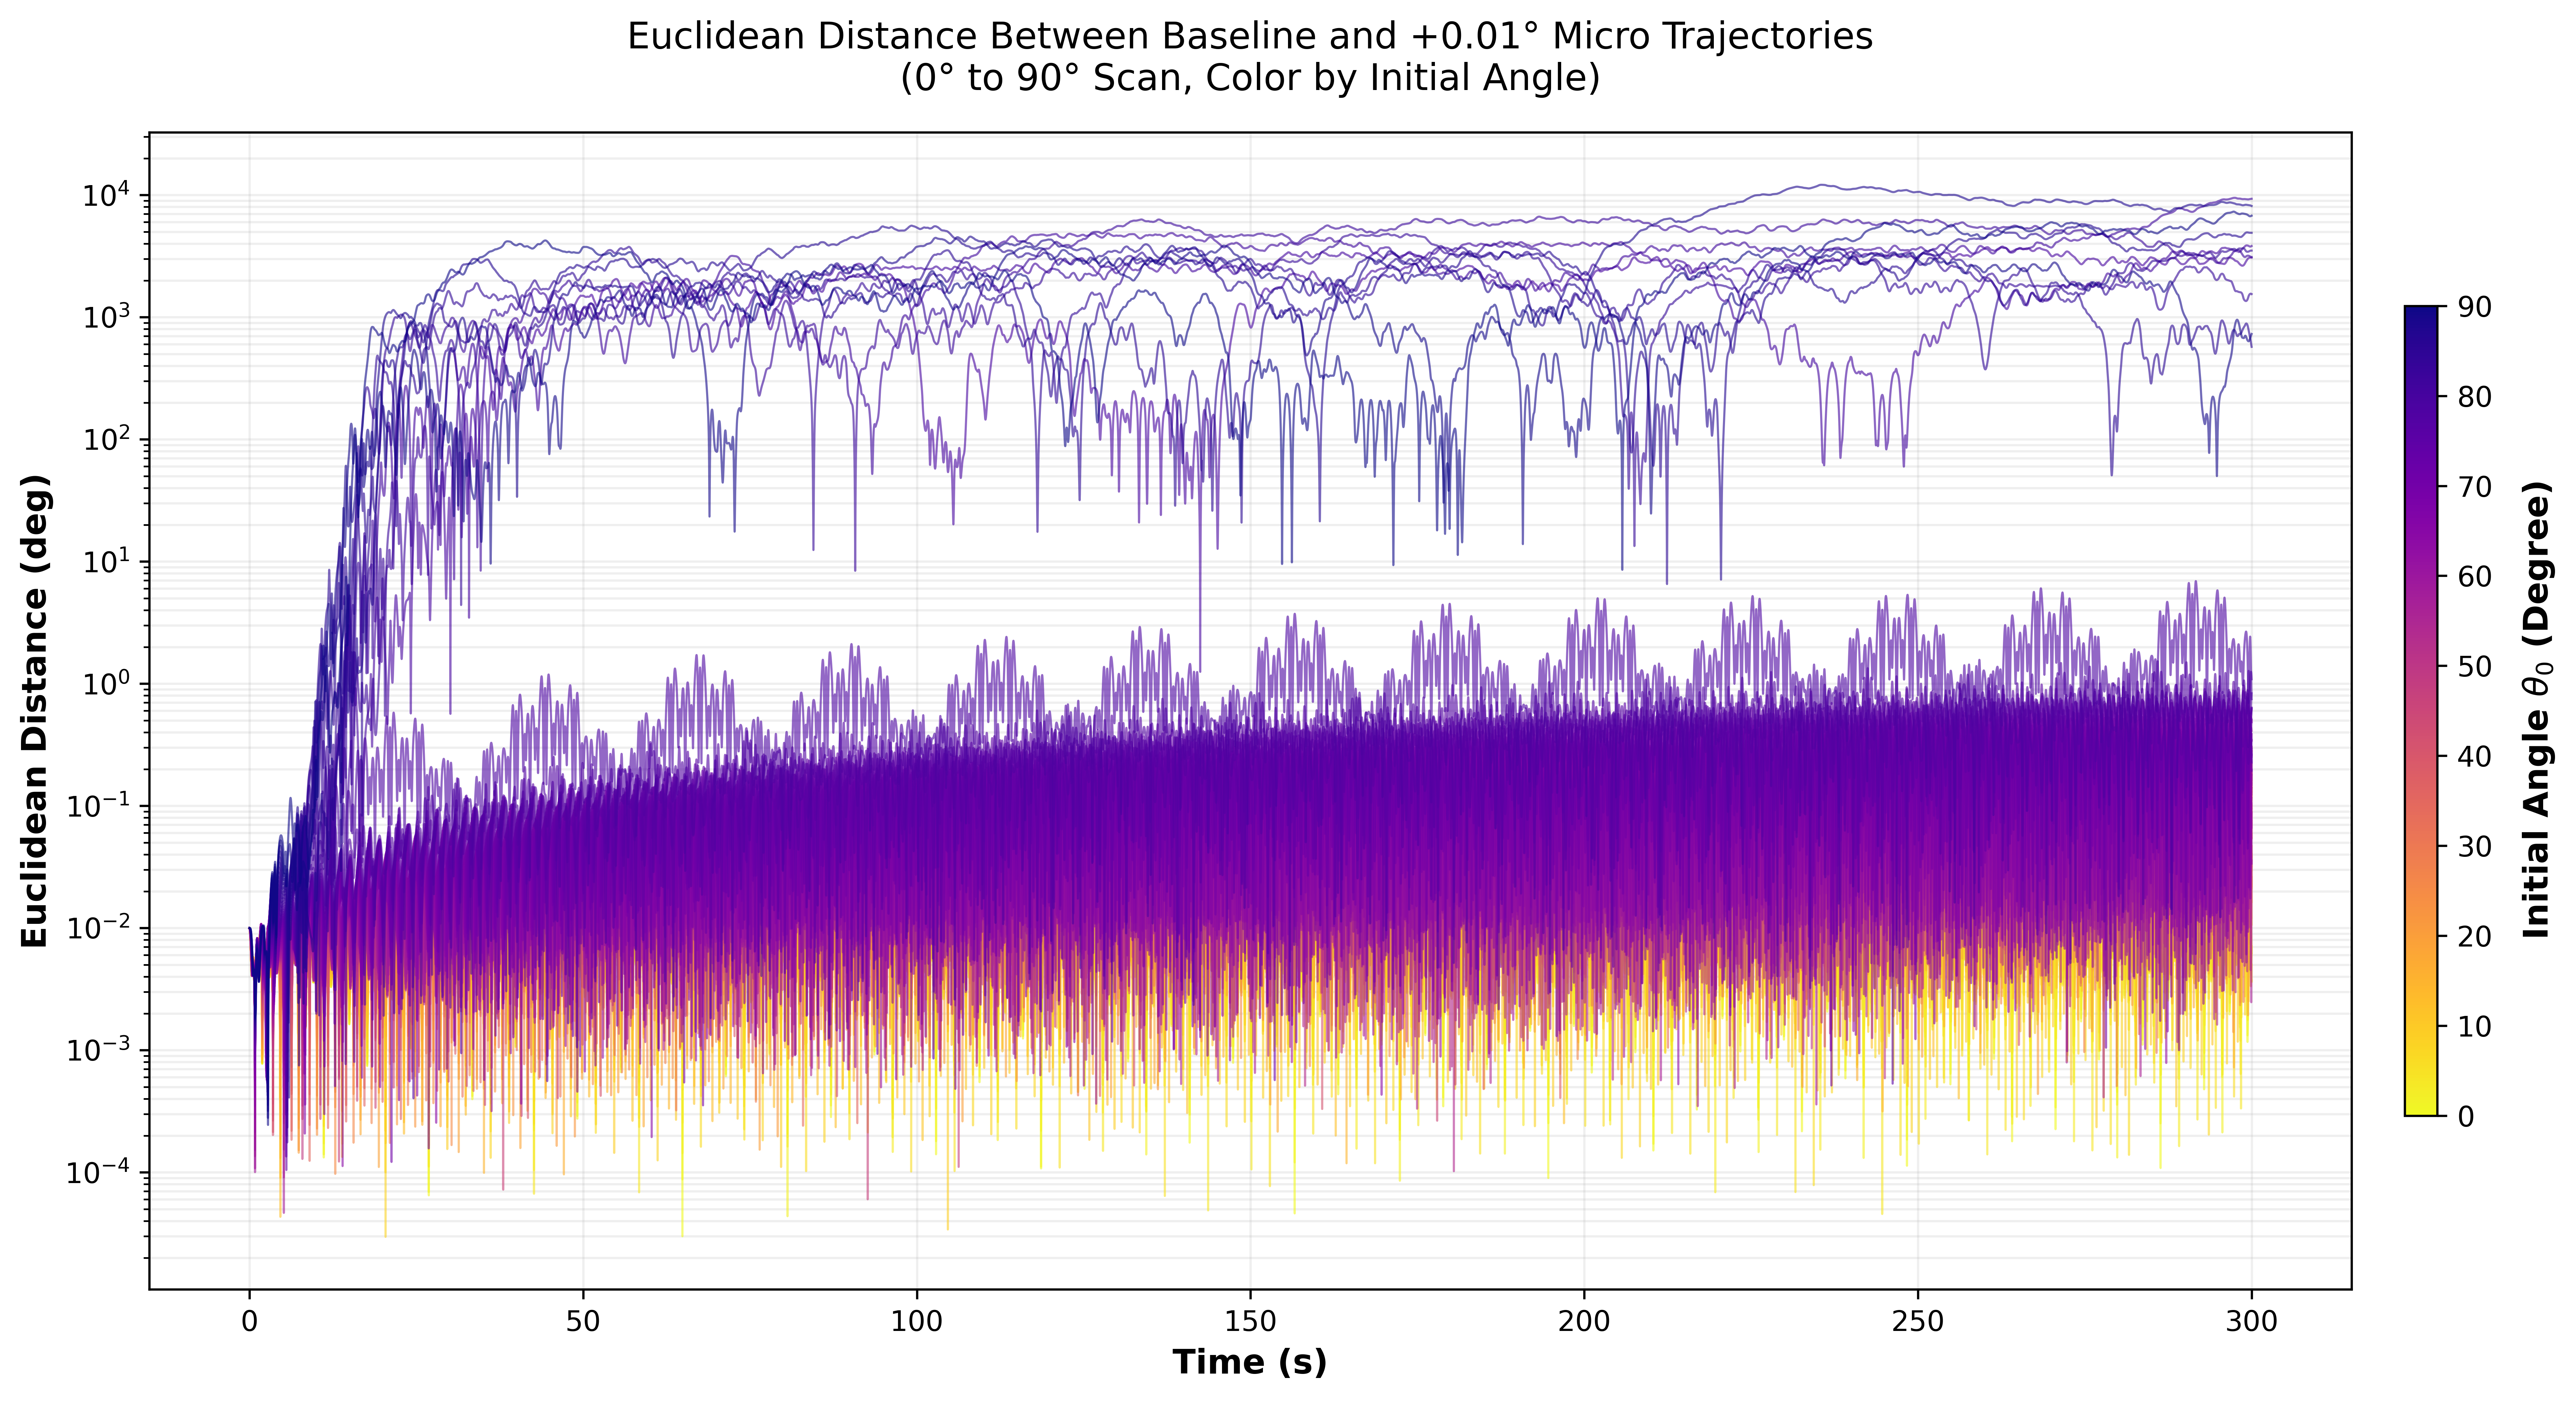

✅ 共绘制 91 条线 (0°~90°)


In [4]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors

# 时间轴
time = np.arange(len(distance_tables[0])) * 0.01

# 颜色映射
vmin, vmax = 0, 90
norm = colors.Normalize(vmin=vmin, vmax=vmax)
cmap = cm.get_cmap("plasma_r")  # 等离子体色，反转（深色=小角度）

# 创建画布
fig, ax = plt.subplots(figsize=(14, 7), dpi=600)

# 遍历所有角度
for angle in angle_groups:
    dist = distance_tables[angle]
    line_color = cmap(norm(angle))
    
    # 对数纵坐标，所以把距离为0的点过滤掉（取个极小值避免log(0)）
    dist_plot = np.maximum(dist, 1e-10)
    
    ax.plot(time, dist_plot, color=line_color, lw=0.75, alpha=0.6)

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02, shrink=0.7, aspect=25)
cbar.set_label(r"Initial Angle $\theta_0$ (Degree)", fontsize=12, fontweight="bold", labelpad=10)

# 标签
ax.set_xlabel("Time (s)", fontweight="bold", fontsize=12)
ax.set_ylabel("Euclidean Distance (deg)", fontweight="bold", fontsize=12)
ax.set_title("Euclidean Distance Between Baseline and +0.01° Micro Trajectories\n(0° to 90° Scan, Color by Initial Angle)", fontsize=13, pad=15)

ax.set_yscale("log")
ax.grid(True, which="both", alpha=0.2)

plt.tight_layout()
plt.savefig("experiment_4_scan.png", dpi=600, bbox_inches='tight')
plt.savefig("experiment_4_scan.pdf", bbox_inches='tight')
plt.show()

print(f"✅ 共绘制 {len(angle_groups)} 条线 (0°~90°)")

Text(0.5, 1.0, 'Euclidean Distance Between Baseline and Micro Trajectories (0°~90° Scan)')

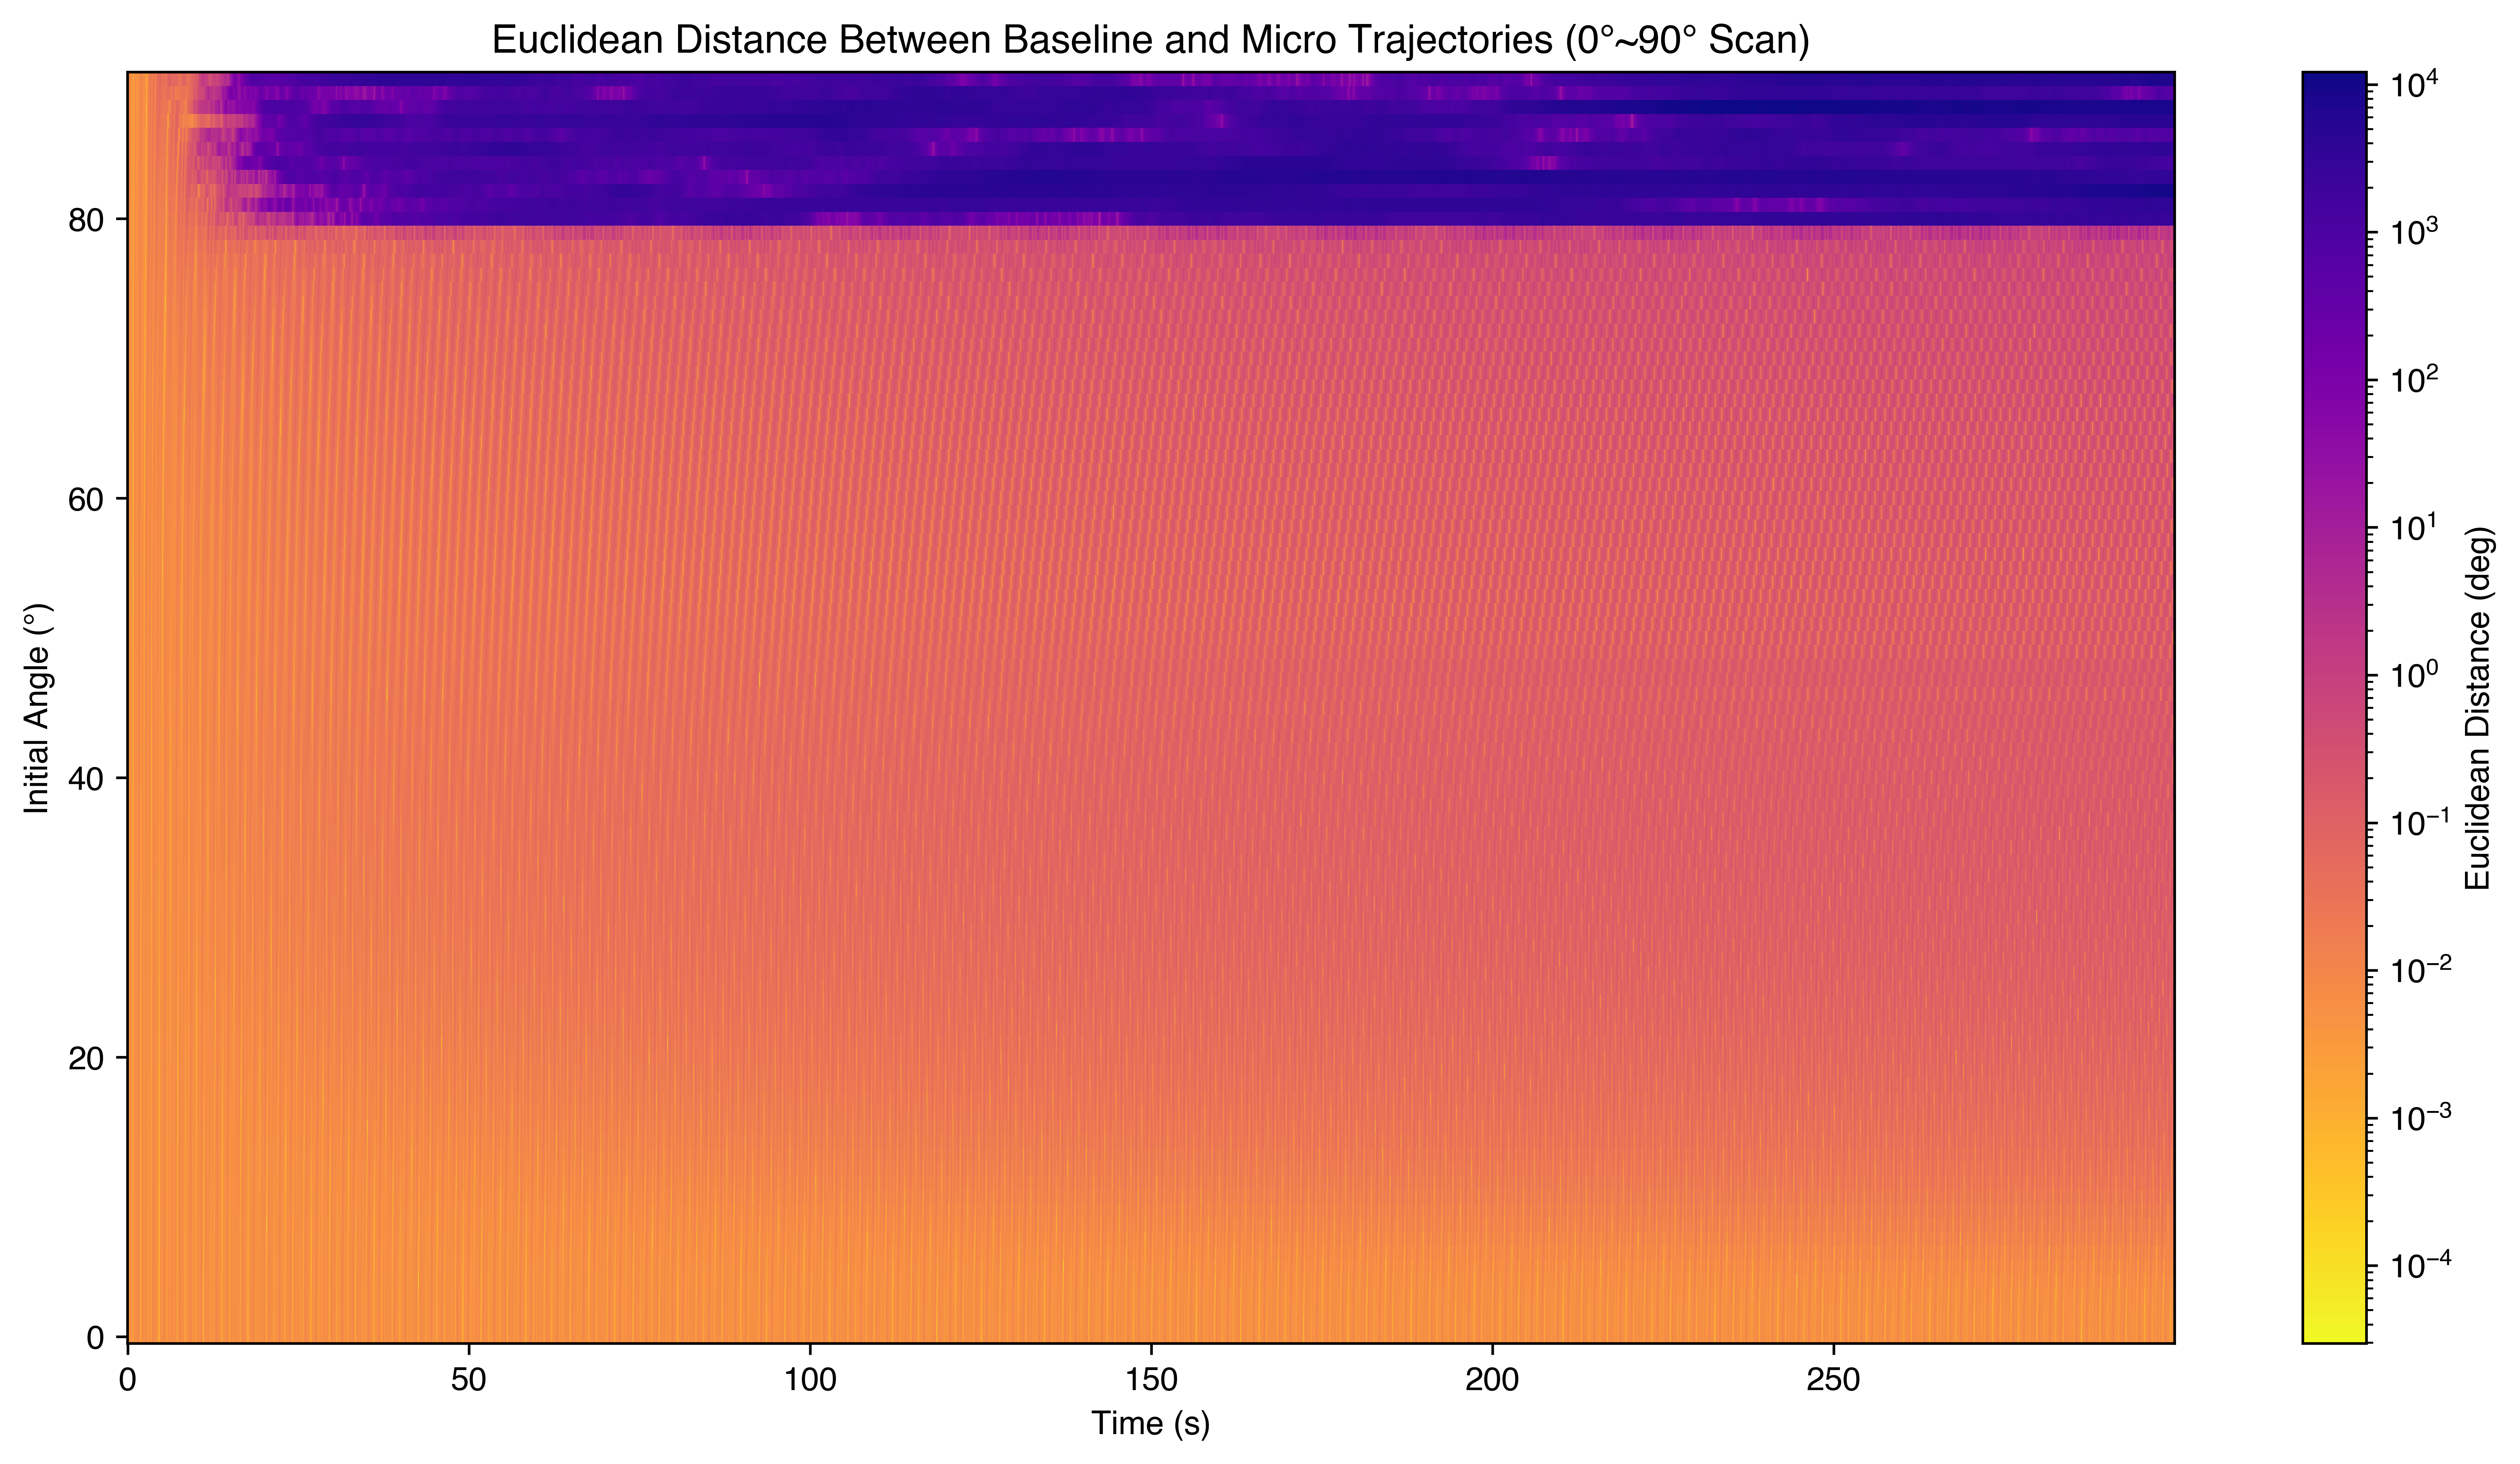

In [7]:
# 构造二维数组: shape = (角度数, 时间步数)
dist_matrix = np.array([distance_tables[angle] for angle in angle_groups])

fig, ax = plt.subplots(figsize=(14, 7), dpi=600)

# 用 pcolormesh 画
X, Y = np.meshgrid(time, angle_groups)
c = ax.pcolormesh(X, Y, dist_matrix, shading='auto', cmap='plasma_r', norm=colors.LogNorm())

cbar = fig.colorbar(c, ax=ax)
cbar.set_label("Euclidean Distance (deg)")

ax.set_xlabel("Time (s)")
ax.set_ylabel("Initial Angle (°)")
ax.set_title("Euclidean Distance Between Baseline and Micro Trajectories (0°~90° Scan)")

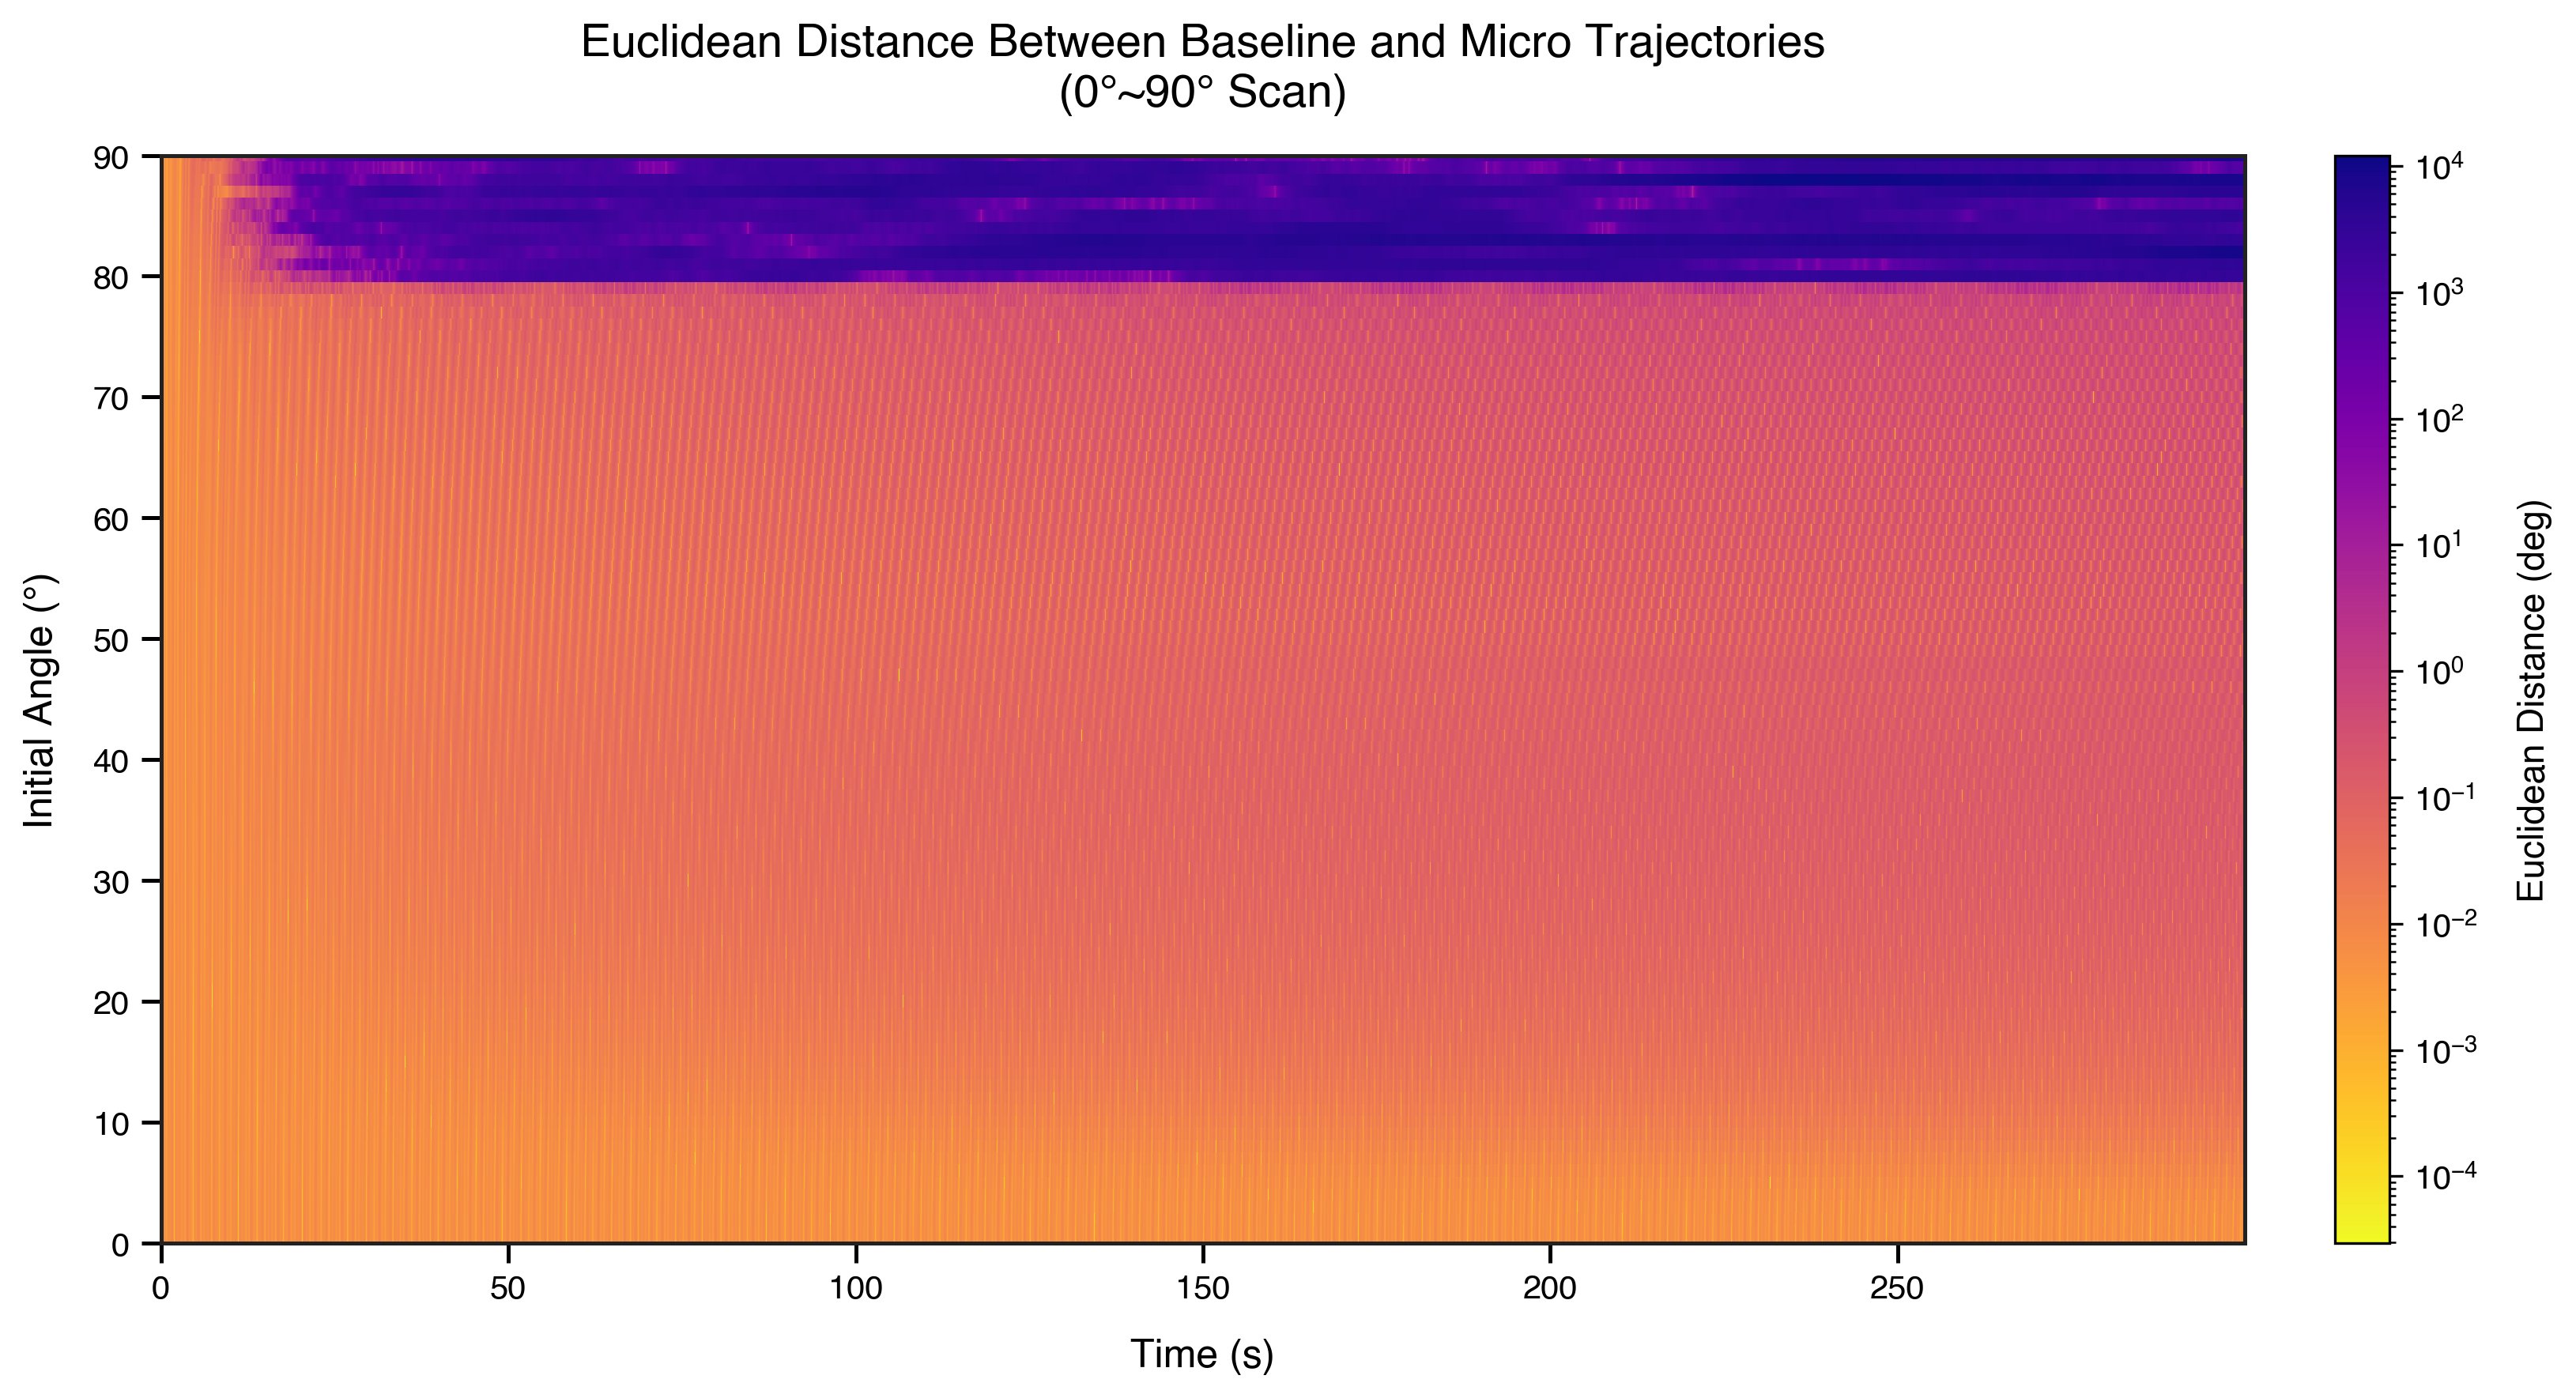

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker

# --- 1. 设置全局科研图表样式 ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 正常显示负号

# 构造画布 (适当减小默认 dpi，出图时 300 已经非常清晰且渲染更快)
fig, ax = plt.subplots(figsize=(11, 6), dpi=300)

# --- 2. 核心绘图优化 ---
X, Y = np.meshgrid(time, angle_groups)

# 使用 viridis 或 inferno 通常比 plasma_r 在对数尺度下视觉过渡更平滑
# 如果依然喜欢原有色系，可以使用 'magma' 或调整过的 'plasma'
cmap = plt.cm.plasma_r

c = ax.pcolormesh(X, Y, dist_matrix, 
                  shading='nearest',  # 明确指定像素对齐方式
                  cmap=cmap, 
                  norm=colors.LogNorm(vmin=dist_matrix.min(), vmax=dist_matrix.max()))

# --- 3. 坐标轴与细节微调 (Axes Tweak) ---
ax.set_xlabel("Time (s)", fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel("Initial Angle (°)", fontsize=12, fontweight='bold', labelpad=10)
ax.set_title("Euclidean Distance Between Baseline and Micro Trajectories\n(0°~90° Scan)", 
             fontsize=14, fontweight='bold', pad=15)

# 限制坐标轴范围，防止四周留白
ax.set_xlim(min(time), max(time))
ax.set_ylim(min(angle_groups), max(angle_groups))

# 调整刻度字号与方向
ax.tick_params(axis='both', which='major', labelsize=10, direction='out', length=6, width=1.2)
ax.tick_params(axis='both', which='minor', direction='out', length=3, width=1.0)

# 强化四周的边框质感（稍微加粗，颜色改用深灰而非纯黑，显得高级）
for spine in ax.spines.values():
    spine.set_linewidth(1.2)
    spine.set_color('#222222')

# --- 4. 颜色条高级定制 (Colorbar) ---
# 使用 fraction 和 pad 自动保持右侧完美对齐
cbar = fig.colorbar(c, ax=ax, fraction=0.035, pad=0.04)
cbar.set_label("Euclidean Distance (deg)", fontsize=11, fontweight='bold', labelpad=12)

# 对数坐标的颜色条刻度美化，自动生成 10^n 形式的标记
cbar.ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
cbar.ax.tick_params(labelsize=10, direction='out', length=4)


#plt.savefig("experiment_4_pcolormesh.pdf", bbox_inches = 'tight')
plt.savefig("experiment_4_pcolormesh.png", bbox_inches = 'tight', dpi = 600)
# --- 5. 紧凑布局 ---
plt.tight_layout()
plt.show()